In [1]:
import sympy
import numpy as np
import time
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import networkx as nx
import pickle
from scipy.signal import savgol_filter

from dataclasses import dataclass
from typing import List, Tuple

from ConservationLaws import *


In [129]:
# --- Simulation and Analysis of Random Reaction Networks ---

num_reps = 100

# Parameters for the system
n_cons = 2           # Number of conservation laws
n_reactions = 8      # Number of reactions
n_species = 6       # Number of species
force_reverse_reactions = False  # Force all reactions to have a reverse reaction
k_fac = 2 if force_reverse_reactions else 1  # Factor to account for reverse reactions in rate constant generation

# Random seed for reproducibility
seed = np.random.randint(0, 1000000)

seed = 20
np.random.seed(seed)

# Probability distribution for conservation law entries (e.g., [2,2] means 0 and 1 equally likely)
reac_order = 1
probs = np.array([2, 2])
probs = probs / sum(probs)

reac_order = 2
probs = np.array([4, 6, 2])
probs = probs / sum(probs)

method = 'LSODA'
rtol = 1e-3
atol = 1e-6 

# reac_order = 2
# probs = np.array([10, 2, 2])
# probs = probs / sum(probs)

# Timeouts for random search
outer_timeout = 40   # seconds for the outer loop
inner_timeout = 1    # seconds for the inner loop in generate_stoichiometry_matrix

# Magnitude for initial conditions and rate constants
y_mag = 2
k_mag = 5

# Time span and evaluation points for ODE integration
t_span = (0, 100)  # time interval
dt = 1e-3
# Number of time points to evaluate
t_eval = np.linspace(*t_span, int(t_span[1]/dt))

# Input perturbation settings
input_type = 'rate'  # or 'concentration'
input_range = k_fac * n_reactions  # number of possible input indices
input_vals = np.linspace(-10, 5, 31)  # range of input values to scan

# input_type = 'concentration'
# input_range = n_species  # number of possible input indices
# dv = 0.02
# crange = 5
# input_vals =  np.linspace(0, crange, int(crange/dv))

L_list = []
S_list = []
k_list = []
y0_list = []
k_values_list = []
odes_list = []
reaction_network_list = []
turning_points_list = []
ss_response_list = []
G_list = []

for rep in range(num_reps):

    # --- Randomly generate valid conservation laws and stoichiometry matrix ---
    success = False
    start_time = time.time()
    while not success:
        # Sample random conservation laws matrix
        L = random_conservation_laws(n_cons, n_species, probs, seed=None)
        try:
            # Try to generate a valid stoichiometry matrix
            A = generate_stoichiometry_matrix(L, n_reactions, reac_order=reac_order, force_reverse_reactions=force_reverse_reactions, seed=None, timeout=inner_timeout)
            success = True  # Only set to True if no error is raised
        except ValueError as e:
            # If time limit exceeded, raise error
            if time.time() - start_time > outer_timeout:
                raise ValueError("Timeout reached while running outer loop.")
            continue  # Otherwise, try again
    
    end_time = time.time()
    # print(f"Time taken to generate stoichiometry matrix: {end_time - start_time} seconds")
    # --- Build ODEs and reaction network ---
    S, k, odes, reaction_network, rate_exprs = build_mass_action_odes(A, Reaction)

    # --- Set up initial conditions and rate constants ---
    y0 = y_mag * np.random.rand(n_species)
    k_values = k_mag * np.random.rand(k_fac * n_reactions)

    # Lambdify ODEs for numerical integration
    ode_func = sympy.lambdify((S, k), odes, modules='numpy')
    def rhs(t, y, k_values):
        return np.array(ode_func(y, k_values)).flatten()

    ss_responses = []
    try:
        for input_idx in range(input_range):        
            ss_response = compute_ss_response_as_function_of_input(rhs, k_values, y0, t_span, t_eval, input_type, input_idx, input_vals, method = method, rtol = rtol, atol = atol, time_limit = 10)
            ss_responses.append(ss_response)
    except TimeoutError:
        #ss_responses.append(np.zeros_like(ss_response))
        print(f"Timeout error for input {input_idx}")
    except RuntimeWarning as e:
        print(f"Aborted due to RuntimeWarning: {e}")



    G = reaction_network_to_bipartite_graph(reaction_network, n_species)
    
    L_list.append(L)
    S_list.append(S)
    k_list.append(k)
    y0_list.append(y0)
    k_values_list.append(k_values)
    odes_list.append(odes)
    reaction_network_list.append(reaction_network)
    ss_response_list.append(ss_responses) 
    G_list.append(G)

    if rep%10 == 0:
        print(rep)




0
10
20
30
40
50
60
70
80
90


In [5]:
turning_points_list = recompute_turning_points_list(ss_response_list, eps=1e-3, smooth=True, window_length=5, polyorder=1, prominence=1e-3, wlen=5)

/Users/csfloyd/Library/CloudStorage/Dropbox/Projects/GlycanAnalysis/repositories/GlycanAnalysis/Python/ConservationLaws.py:242: PeakPropertyWarning: some peaks have a prominence of 0
  peaks, _ = find_peaks(y, prominence=prominence, wlen=wlen)
/Users/csfloyd/Library/CloudStorage/Dropbox/Projects/GlycanAnalysis/repositories/GlycanAnalysis/Python/ConservationLaws.py:244: PeakPropertyWarning: some peaks have a prominence of 0
  valleys, _ = find_peaks(-y, prominence=prominence, wlen=wlen)


In [130]:
path = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/Irr_FO_2sparseconstr_n.apkl'
export_data_as_apkl(path, L_list, S_list, k_list, y0_list, k_values_list, odes_list, reaction_network_list, ss_response_list, G_list)

data = import_data_from_apkl(path)
L_list = data['L_list']
S_list = data['S_list']
k_list = data['k_list']
y0_list = data['y0_list']
k_values_list = data['k_values_list']
odes_list = data['odes_list']
reaction_network_list = data['reaction_network_list']
ss_response_list = data['ss_response_list']
G_list = data['G_list']


Data exported to /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/Irr_FO_2sparseconstr_n.apkl


In [131]:
#path = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/Rev_SO_1sparseconstr.apkl'
path = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/Irr_FO_2sparseconstr_n.apkl'
#path = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/NSC_FO.apkl'

data = import_data_from_apkl(path)
S_list = data['S_list']
y0_list = data['y0_list']
k_values_list = data['k_values_list']
k_list = data['k_list']
odes_list = data['odes_list']
reaction_network_list = data['reaction_network_list']
ss_response_list = data['ss_response_list']
G_list = data['G_list']
turning_points_list_nested = recompute_turning_points_list(ss_response_list, eps=1e-3, smooth=True, window_length=5, polyorder=1, prominence=1e-3, wlen=5)
turning_points_list = [np.array(item) for item in turning_points_list_nested]
thresh_array = compute_above_threshold(ss_response_list, 1e2)



/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/repositories/GlycanAnalysis/Python/ConservationLaws.py:262: PeakPropertyWarning: some peaks have a prominence of 0
  peaks, _ = find_peaks(y, prominence=prominence, wlen=wlen)
/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/repositories/GlycanAnalysis/Python/ConservationLaws.py:264: PeakPropertyWarning: some peaks have a prominence of 0
  valleys, _ = find_peaks(-y, prominence=prominence, wlen=wlen)


[0. 0. 0. ... 0. 0. 1.]
[ True  True  True ...  True  True  True]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0

(array([2.187e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.370e+02,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

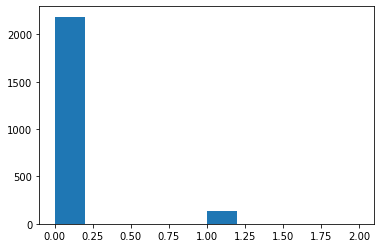

In [117]:
tpl = np.array([item.flatten() for sublist in turning_points_list for item in sublist]).flatten().flatten()
thpl = np.array([item.flatten() for sublist in thresh_array for item in sublist]).flatten().flatten()
print(tpl)
print(thpl)
tpl_within_thresh = [tpl[i] for i in range(len(tpl)) if thpl[i]]
print(tpl_within_thresh)
plt.hist(tpl_within_thresh)

Text(0.5, 1.0, 'Distribution of turning points across reaction networks')

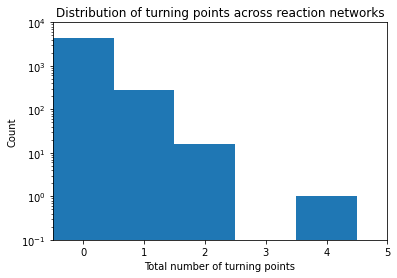

In [132]:
tpl = np.array([item.flatten() for sublist in turning_points_list for item in sublist]).flatten().flatten()
thpl = np.array([item.flatten() for sublist in thresh_array for item in sublist]).flatten().flatten()
tpl_within_thresh = [tpl[i] for i in range(len(tpl)) if thpl[i]]
plt.figure()
bmin = 0
bmax = 4
bins = np.arange(-0.5, 5.5)  # Shift bins so centers are at integer values
plt.hist(tpl_within_thresh, bins=bins, align='mid')
plt.xlabel('Total number of turning points')
plt.ylabel('Count')
plt.yscale('log')
plt.ylim(1e-1,1e4)
plt.xlim(bmin-0.5,bmax-0.5)
plt.xticks(range(bmin,bmax+2))
plt.title('Distribution of turning points across reaction networks')

In [79]:
# path1 = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/Rev_SO_1sparseconstr.apkl'
# path2 = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/Irr_SO_1sparseconstr.apkl'

# paths = [path1, path2]
# titles = ['Reversible', 'Irreversible']

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), facecolor='white')
# bmin, bmax = 0, 2
# bins = np.arange(-0.5, 3.5)

# for path, title, ax in zip(paths, titles, [ax1, ax2]):
#     data = import_data_from_apkl(path)
#     ss_response_list = data['ss_response_list']
#     turning_points_list = recompute_turning_points_list(ss_response_list, eps=1e-3, smooth=True, window_length=5, polyorder=1, prominence=1e-3, wlen=5)
    
#     tpl = np.array(turning_points_list, dtype=int).flatten().flatten()
#     ax.hist(tpl, bins=bins, align='mid')
#     ax.set_xlabel('Total number of turning points')
#     ax.set_ylabel('Count')
#     ax.set_yscale('log')
#     ax.set_ylim(1, 2e4)
#     ax.set_xlim(bmin-0.5, bmax-0.5)
#     ax.set_xticks(range(bmin, bmax+2))
#     ax.set_title(f'{title} reactions')


# plt.tight_layout()
# plt.savefig('/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/RevIrrevTurningPointsSO.png', dpi=300)


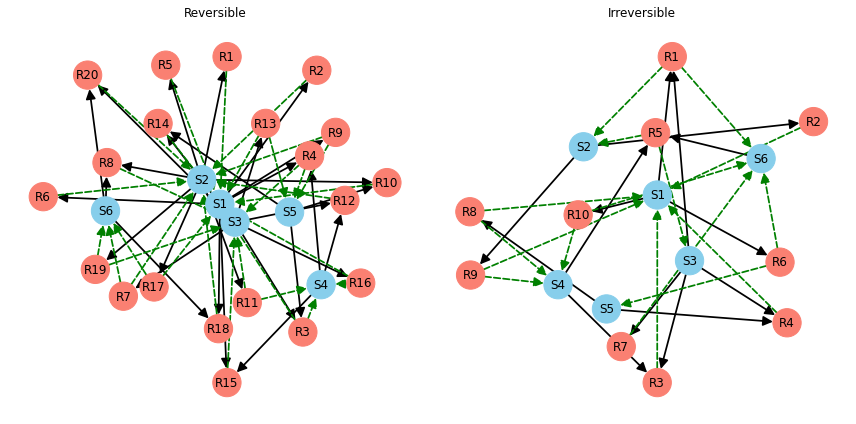

In [114]:
path1 = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/Rev_SO_1sparseconstr.apkl'
path2 = '/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/PythonOutput/Irr_SO_1sparseconstr.apkl'

paths = [path1, path2]
titles = ['Reversible', 'Irreversible']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white')
bmin, bmax = 0, 1
bins = np.arange(-0.5, 3.5)
ax1.set_title('Reversible')
ax2.set_title('Irreversible')

for path, title, ax in zip(paths, titles, [ax1, ax2]):
    data = import_data_from_apkl(path)
    G_list = data['G_list']
    G = G_list[3]
    draw_bipartite_reaction_network(G, ax=ax)

plt.tight_layout()
plt.savefig('/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/RevIrrevReactionGraphsSO.png', dpi=300)

[1.0, 2.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 14.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 4.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 2.0, 2.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 2.0, 0.0, 2.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 2.0, 1.0, 1.0, 5.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 2.0, 1.0, 1.0, 0.0]
12
[[0. 0. 0. 0. 0. 4.]
 [2. 0. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0. 0.]]
[[ True  True  True  True  True  True]
 [ True  True  True  True  True  True]
 [ True  True  True  True  True  True]
 [ True  True  True  True  True  True]
 [ True  True  True  True  True  True]
 [ True  True  True  True  True  True]
 [ True  True  True  True  True  True]
 [ True  True  True  True  True  True]]
[5.06121897 5

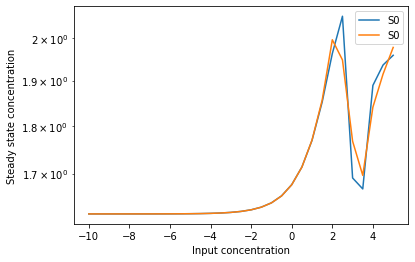

In [151]:
from scipy.signal import find_peaks

thresh_array = compute_above_threshold(ss_response_list, 1e3)
n_species = 6
sum_list = []
max_list = []
ind_list = []
for (i, turning_points) in enumerate(turning_points_list):
    if turning_points.shape[0] > 1:
        sum_list.append(sum(sum(turning_points)))
        max_list.append(np.max(np.max(turning_points)))
        ind_list.append(i)
print(max_list)
trial_ind = ind_list[np.argmax(max_list)]
print(trial_ind)

trial_ind = 26
print(np.array(turning_points_list[trial_ind]))
print(np.array(thresh_array[trial_ind]))

input_vals = np.linspace(-10, 5, 31)  # range of input values to scan

# ## --- Plot steady-state response curves ---
# ss_ind = 4
# for i in range(ss_responses[ss_ind].shape[1]):
#     plt.plot(input_vals, ss_responses[ss_ind][:, i], label=f'S{i+1}')


ss_ind = 0
k_ind = -1
y = ss_response_list[trial_ind][ss_ind][:, k_ind]
print(sum([ss_response_list[trial_ind][ss_ind][:,k_ind] for k_ind in range(n_species)]))
prom = 1e-3
wlen = 5
peaks, _ = find_peaks(y, prominence=prom, wlen = wlen)
valleys, _ = find_peaks(-y, prominence=prom, wlen = wlen)
print(peaks)
print(valleys)
plt.plot(input_vals, y, label=f'S{k_ind+1}')

y_smooth = smooth_curve(y, window_length=3, polyorder=2)
mean_val = np.mean(y_smooth)


print(count_turning_points(y, eps=1e-3, window_length=1, polyorder=2, wlen = 10, smooth = True))
plt.plot(input_vals, y_smooth, label=f'S{k_ind+1}')

plt.xlabel('Input concentration')
plt.ylabel('Steady state concentration')
plt.yscale('log')
plt.legend()

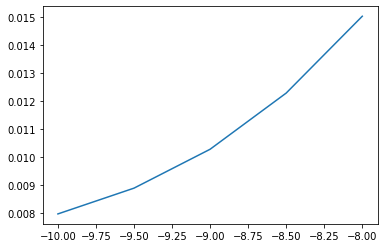

In [124]:
plt.plot(input_vals[:5], y[:5], label=f'S{k_ind+1}')

R1: S4 -> S6
R2: S1 -> S3
R3: S3 -> S4
R4: S4 -> S3
R5: S5 -> S3
R6: S5 -> S1
R7: S5 -> S4
R8: S1 -> S4
R9: S3 -> S5
R10: S4 -> S5


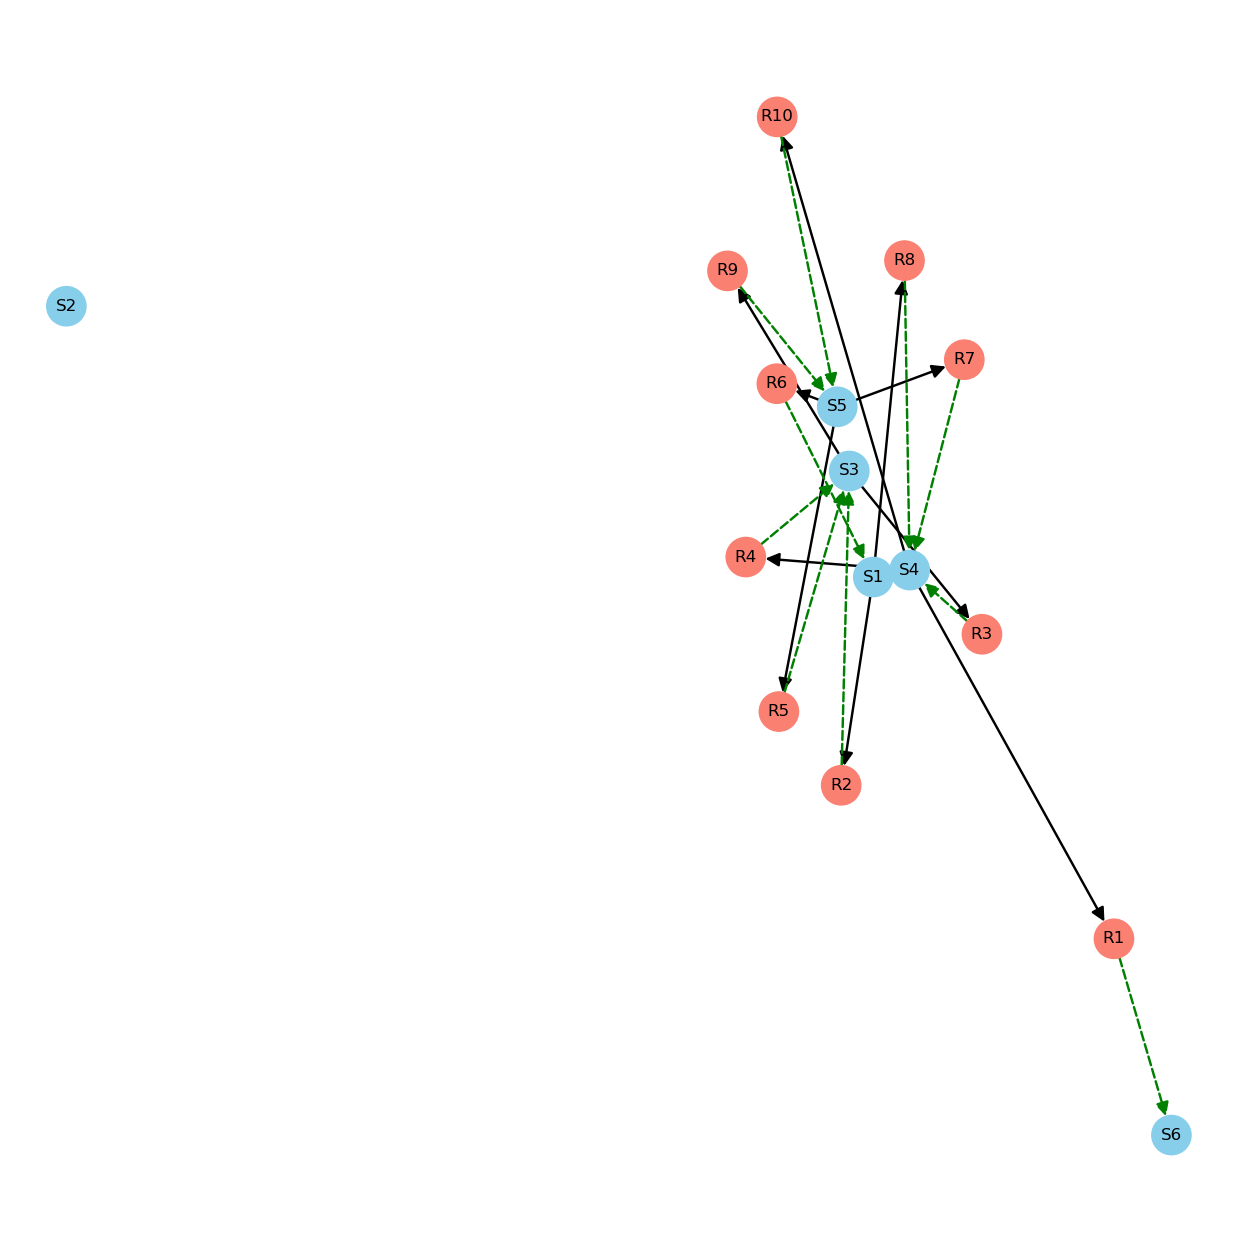

In [13]:
fig, (ax) = plt.subplots(1, 1, figsize=(16, 16), facecolor='white')
G_list = data['G_list']
reaction_network_list = data['reaction_network_list']
print_reaction_network(reaction_network_list[trial_ind])

G = G_list[trial_ind]
draw_bipartite_reaction_network(G, ax=ax)

In [152]:
S = S_list[trial_ind]
k = k_list[trial_ind]
odes = odes_list[trial_ind]
y0 = y0_list[trial_ind]
k_values = k_values_list[trial_ind]

ode_func = sympy.lambdify((S, k), odes, modules='numpy')
def rhs(t, y, k_values):
    return np.array(ode_func(y, k_values)).flatten()

# Lambdify ODEs for numerical integration
ode_func = sympy.lambdify((S, k), odes, modules='numpy')
def rhs(t, y, k_values):
    return np.array(ode_func(y, k_values)).flatten()

input_range = k_fac * n_reactions  # number of possible input indices
input_vals = np.linspace(0, 5, 81)  # range of input values to scan
# Time span and evaluation points for ODE integration
t_span = (0, 50)  # time interval
dt = 1e-4
# Number of time points to evaluate
t_eval = np.linspace(*t_span, int(t_span[1]/dt))

ss_responses = []
for input_idx in range(input_range):
    ss_response = compute_ss_response_as_function_of_input(rhs, k_values, y0, t_span, t_eval, input_type, input_idx, input_vals, method = method, rtol = rtol, atol = atol, time_limit = 20)
    ss_responses.append(ss_response)

sol = solve_ivp(rhs, t_span, y0, args=(k_values,), t_eval=t_eval, method=method, rtol=rtol, atol=atol)



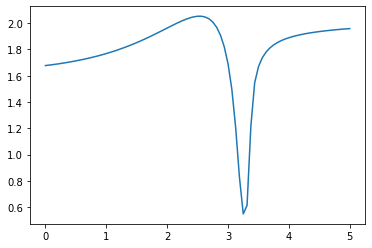

In [153]:
y = ss_responses[ss_ind][:, k_ind]
plt.plot(input_vals, y, label=f'S{k_ind+1}')

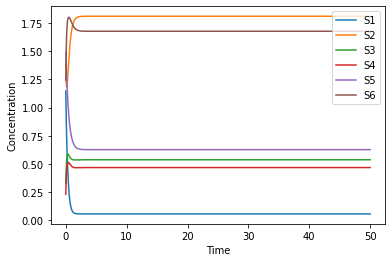

In [149]:
for i in range(n_species):
    plt.plot(sol.t, sol.y[i], label=f'S{i+1}')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.legend()
plt.show()

Matrix([[0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 1]])


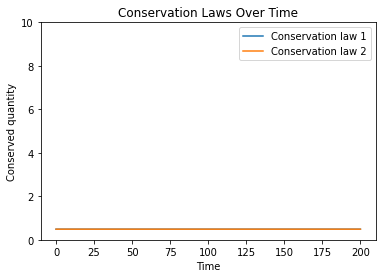

In [113]:
L = L_list[trial_ind]
print(L)

# If L is a sympy Matrix, convert to numpy
L_np = np.array(L).astype(float)  # shape: (n_laws, n_species)
S_sol = sol.y                     # shape: (n_species, n_timepoints)

# Compute conserved quantities at each timepoint
Q = L_np @ S_sol  # shape: (n_laws, n_timepoints)

# Plot each conserved quantity over time
for i in range(Q.shape[0]):
    plt.plot(sol.t, Q[i], label=f'Conservation law {i+1}')
plt.xlabel('Time')
plt.ylim(0,10)
plt.ylabel('Conserved quantity')
plt.legend()
plt.title('Conservation Laws Over Time')
plt.show()